<a href="https://colab.research.google.com/github/hsmu-jeongeun/health-infomatics/blob/main/04_Keyword_Extraction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 4주차 실습: 간호 기록 키워드 추출 및 매핑

## 학습 목표
- 비정형 텍스트(간호 기록)에서 핵심 키워드를 추출할 수 있다
- Python 딕셔너리로 키워드를 표준 코드로 매핑할 수 있다
- 자연어 처리(NLP)의 기초 개념을 이해할 수 있다

---

## 오늘의 핵심 개념: 프리텍스트를 코드로

> 간호사가 차트에 '환자가 심한 두통과 함께 오심을 호소함'이라고 적으면, 이 문장을 컴퓨터는 읽기 어렵습니다. 하지만 '두통 → R51, 오심 → R11'처럼 코드로 변환하면, 전 세계 병원 데이터와 비교 분석할 수 있게 됩니다.

### 표준용어체계의 필요성
- **ICD-10:** 국제질병분류코드. WHO가 관리하는 글로벌 표준
- **SNOMED-CT:** 임상 개념의 표준 용어 체계
- **ICNP:** 간호 전용 국제 표준 용어 (간호진단, 중재, 결과 포함)
- **핵심:** 비정형 텍스트 → 구조화된 코드 변환 = **NLP(자연어 처리)** 의 역할

### 자연어 처리(NLP)란?
- 컴퓨터가 사람의 언어를 이해하고 처리하는 기술
- 현재 ChatGPT 등 LLM의 근간
- 의료에서 활용: 진단명 추출, 약물-부작용 관계 분석, 임상 노트 요약 등

In [1]:
# 필요한 라이브러리 불러오기
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
#matplotlib.rcParams['font.family'] = 'NanumGothic'
#matplotlib.rcParams['axes.unicode_minus'] = False

print('라이브러리 로드 완료')

라이브러리 로드 완료


## 가상의 표준 코드 매핑 딕셔너리 생성

실제 ICNP/ICD-10 코드 기반으로 만든 간략화된 매핑 테이블

In [2]:
# 키워드 → 표준 코드 매핑 딕셔너리
# 형식: '키워드': ('코드', '카테고리')
keyword_map = {
    # 통증 관련
    '통증':     ('PAIN-001', 'PAIN'),
    '아픔':     ('PAIN-001', 'PAIN'),
    '쑤심':     ('PAIN-002', 'PAIN'),
    '압박감':   ('PAIN-003', 'PAIN'),
    '두통':     ('PAIN-004', 'PAIN'),
    '복통':     ('PAIN-005', 'PAIN'),
    # 호흡기 관련
    '호흡곤란': ('RESP-001', 'RESP'),
    '기침':     ('RESP-002', 'RESP'),
    '객담':     ('RESP-003', 'RESP'),
    '천명':     ('RESP-004', 'RESP'),
    # 소화기 관련
    '오심':     ('GI-001', 'GI'),
    '구토':     ('GI-002', 'GI'),
    '설사':     ('GI-003', 'GI'),
    '변비':     ('GI-004', 'GI'),
    # 활력징후 이상
    '발열':     ('FEVER-001', 'FEVER'),
    '오한':     ('FEVER-002', 'FEVER'),
    '저혈압':   ('VS-001', 'VS'),
    '빈맥':     ('VS-002', 'VS'),
    # 신경계
    '어지러움': ('NEURO-001', 'NEURO'),
    '의식저하': ('NEURO-002', 'NEURO'),
    '혼돈':     ('NEURO-003', 'NEURO'),
}

print(f'매핑 키워드 수: {len(keyword_map)}개')
print('\n일부 매핑 확인:')
for kw, (code, cat) in list(keyword_map.items())[:5]:
    print(f'  {kw} → {code} ({cat})')

매핑 키워드 수: 21개

일부 매핑 확인:
  통증 → PAIN-001 (PAIN)
  아픔 → PAIN-001 (PAIN)
  쑤심 → PAIN-002 (PAIN)
  압박감 → PAIN-003 (PAIN)
  두통 → PAIN-004 (PAIN)


## 100건의 가상 간호 기록 생성

In [3]:
# 가상의 간호 기록 100건
# 실제 간호 기록을 모사한 비정형 텍스트 데이터
nursing_records = [
    # 통증 관련 기록 (38건)
    '환자가 복부 통증을 심하게 호소함. 통증 척도 7/10.',
    '오전 6시 두통 호소. 진통제 투약 후 완화됨.',
    '수술 부위 통증 지속. 아픔 강도 8/10으로 보고.',
    '등 쪽 압박감 호소. 체위 변경 후 다소 완화.',
    '복통과 함께 오심 동반. 진통제 투약.',
    '두통이 심하다고 보고. 진통제 요청함.',
    '관절 쑤심 호소. ROM 운동 실시.',
    '두통과 어지러움 동반. 활력징후 측정.',
    '상처 부위 통증으로 수면 불량.',
    '복통 호소. 압박감 동반. 의사에게 보고.',
    '두통 지속됨. 통증 수준 6/10.',
    '흉부 압박감 호소. 심전도 모니터링.',
    '요통 호소. 온열 요법 적용.',
    '아픔 호소하며 안절부절함.',
    '수술 후 통증 강도 높음. 진통제 추가 요청.',
    '하복부 통증 지속. 초음파 검사 예정.',
    '두통 새벽부터 지속됨. 조명 노출 피함.',
    '어깨 통증 호소. 물리치료 의뢰.',
    '압박감 동반한 두통. 혈압 체크.',
    '복통 소화제 투약 후 완화됨.',
    '무릎 통증으로 보행 어려움.',
    '두통 심화. 진통 처방 재요청.',
    '쑤심 동반. 항염증제 투약.',
    '통증 척도 9/10. 즉각적인 중재 필요.',
    '복통과 설사 동반됨.',
    '두통 오후부터 시작. 진통제 반응 양호.',
    '수술 부위 아픔 호소.',
    '두통 두 번째 호소. 신경과 협진 요청.',
    '복통 지속 중. 금식 유지.',
    '압박감 호소. 자세 교정 실시.',
    '발목 통증. 냉찜질 적용.',
    '두통 기상 후 발생.',
    '쑤심 통증. ROM 유지 교육.',
    '복부 불편감과 압박감 호소.',
    '진통제 효과 미흡. 통증 지속.',
    '두통 악화. CT 검사 예정.',
    '상복부 통증. 식후 악화 경향.',
    '통증으로 인한 수면 장애 보고.',
    # 호흡기 관련 기록 (18건)
    '호흡곤란 호소. 산소 2L/min 투여.',
    '기침이 심해짐. 객담 증가.',
    '흉부 X-ray 결과 이상 소견. 호흡곤란 지속.',
    '천명음 청진됨. 기관지 확장제 투약.',
    '기침 심화. 객담 노란색으로 변색.',
    '호흡곤란으로 보조 산소 필요.',
    '기침 야간에 악화. 수면 방해.',
    '객담 양 증가. 흡인 실시.',
    '호흡곤란 체위 변경 후 완화.',
    '천명 새로 발생. 의사에게 즉시 보고.',
    '기침 약 투약. 효과 관찰 중.',
    '호흡수 증가. SpO2 95%.',
    '객담 끈적거림. 수분 섭취 격려.',
    '기침 반복. 흉부 물리치료 실시.',
    '호흡곤란 악화. 산소 마스크로 변경.',
    '천명 양측성. 흡입기 사용 교육.',
    '기침에 혈액 섞임. 즉시 의사 보고.',
    '호흡 불규칙. 호흡 모니터링 강화.',
    # 소화기 관련 기록 (15건)
    '오심 호소. 식사 거부.',
    '구토 2회 발생. 수액 투여.',
    '설사 빈번함. 탈수 주의.',
    '변비로 인한 복부 팽만.',
    '오심과 구토 동반. 항구토제 투약.',
    '설사 지속. 전해질 검사 시행.',
    '구토 후 활력징후 안정화.',
    '오심 식전 악화됨.',
    '변비 3일째. 하제 투약 처방.',
    '오심 진정제 투약 후 감소.',
    '설사 혈액 섞임. 의사 즉시 보고.',
    '구토 반복. 금식 처방.',
    '오심 구토 항암 치료 부작용.',
    '변비로 인한 복부 불편감 호소.',
    '구토 심함. 수분 전해질 관리 중.',
    # 발열 관련 기록 (12건)
    '체온 38.5도. 발열 확인. 해열제 투약.',
    '오한과 함께 발열. 혈액 배양 시행.',
    '발열 지속. 항생제 투약 중.',
    '체온 39.2도. 냉각 처치 실시.',
    '오한 발생. 보온 조치 후 체온 측정.',
    '발열 주기적 패턴. 말라리아 검사 의뢰.',
    '오한 심함. 전기담요 제공.',
    '발열 38도. 해열제 효과 관찰.',
    '오한 이후 발열. 요로감염 의심.',
    '발열로 의식 저하 주의.',
    '오한 발생 후 체온 38.8도.',
    '발열 지속. 감염 원인 조사 중.',
    # 기타 기록 (17건)
    '활력징후 안정적. 특이 사항 없음.',
    '환자 수면 취함. 야간 안정적.',
    '혈압 정상 범위. 심박수 안정.',
    '식사량 증가. 회복 경과 양호.',
    '보행 훈련 실시. 낙상 위험 없음.',
    '환자 교육 실시. 이해도 양호.',
    '퇴원 준비 중. 가족 교육 완료.',
    '검사 결과 정상. 의사에게 보고.',
    '수면 불량 호소. 수면 위생 교육.',
    '체중 측정 완료. 체중 감소 없음.',
    '상처 드레싱 교환. 감염 징후 없음.',
    '수액 속도 조절. 부종 감소 중.',
    '어지러움 기립 시 발생. 기립성 저혈압 의심.',
    '저혈압 발생. 수액 증량 처방.',
    '빈맥 측정됨. 심전도 모니터링.',
    '의식저하 발생. 신경과 응급 협진.',
    '혼돈 상태. 섬망 프로토콜 적용.'
]

print(f'총 간호 기록 수: {len(nursing_records)}건')

총 간호 기록 수: 100건


## 키워드 추출 및 표준 코드 매핑

In [4]:
# 각 기록에서 키워드를 찾아 표준 코드 매핑
results = []

for i, record in enumerate(nursing_records):
    matched_codes = []
    matched_categories = []

    for keyword, (code, category) in keyword_map.items():
        if keyword in record:
            matched_codes.append(code)
            matched_categories.append(category)

    results.append({
        '기록번호': i + 1,
        '기록내용': record[:40] + '...' if len(record) > 40 else record,
        '매핑코드': ', '.join(matched_codes) if matched_codes else 'NONE',
        '카테고리': ', '.join(set(matched_categories)) if matched_categories else 'NONE'
    })

result_df = pd.DataFrame(results)
print('키워드 추출 및 코드 매핑 완료!')
print(result_df.head(10))

키워드 추출 및 코드 매핑 완료!
   기록번호                             기록내용                 매핑코드         카테고리
0     1  환자가 복부 통증을 심하게 호소함. 통증 척도 7/10.             PAIN-001         PAIN
1     2       오전 6시 두통 호소. 진통제 투약 후 완화됨.             PAIN-004         PAIN
2     3    수술 부위 통증 지속. 아픔 강도 8/10으로 보고.   PAIN-001, PAIN-001         PAIN
3     4       등 쪽 압박감 호소. 체위 변경 후 다소 완화.             PAIN-003         PAIN
4     5            복통과 함께 오심 동반. 진통제 투약.     PAIN-005, GI-001     GI, PAIN
5     6            두통이 심하다고 보고. 진통제 요청함.             PAIN-004         PAIN
6     7             관절 쑤심 호소. ROM 운동 실시.             PAIN-002         PAIN
7     8            두통과 어지러움 동반. 활력징후 측정.  PAIN-004, NEURO-001  NEURO, PAIN
8     9                상처 부위 통증으로 수면 불량.             PAIN-001         PAIN
9    10          복통 호소. 압박감 동반. 의사에게 보고.   PAIN-003, PAIN-005         PAIN


## 통증(PAIN) 관련 코드가 부여된 횟수 계산

In [5]:
# PAIN 카테고리 코드가 부여된 기록 수 계산
pain_count = result_df['카테고리'].str.contains('PAIN').sum()
print(f'통증(PAIN) 관련 코드가 부여된 기록 수: {pain_count}건')

# 카테고리별 분포 확인
print('\n카테고리별 분포:')
category_counts = {}
for cats in result_df['카테고리']:
    for cat in cats.split(', '):
        if cat != 'NONE':
            category_counts[cat] = category_counts.get(cat, 0) + 1

for cat, count in sorted(category_counts.items(), key=lambda x: -x[1]):
    print(f'  {cat}: {count}건')

통증(PAIN) 관련 코드가 부여된 기록 수: 37건

카테고리별 분포:
  PAIN: 37건
  GI: 17건
  RESP: 16건
  FEVER: 11건
  NEURO: 4건
  VS: 3건


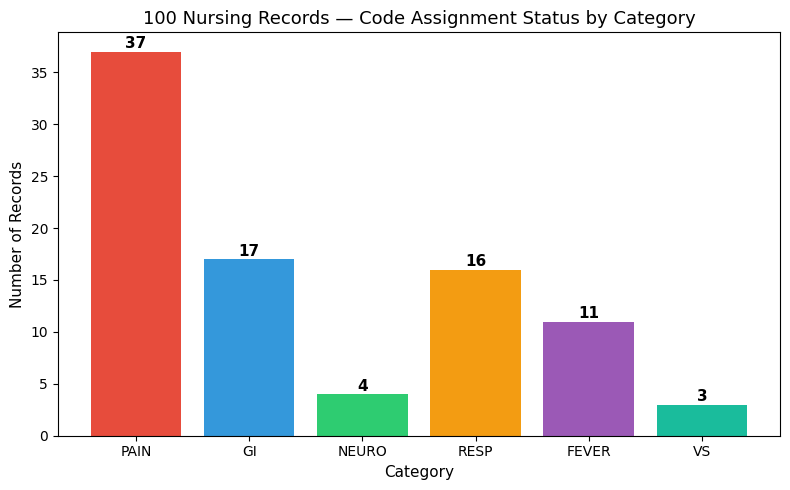

In [6]:
# 카테고리 분포 시각화
fig, ax = plt.subplots(figsize=(8, 5))

cats = list(category_counts.keys())
counts = list(category_counts.values())

bars = ax.bar(cats, counts, color=['#e74c3c', '#3498db', '#2ecc71', '#f39c12', '#9b59b6', '#1abc9c'])
ax.set_title('100 Nursing Records — Code Assignment Status by Category', fontsize=13)
ax.set_xlabel('Category', fontsize=11)
ax.set_ylabel('Number of Records', fontsize=11)

for bar, count in zip(bars, counts):
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.3,
            str(count), ha='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

---

## Canvas 퀴즈 안내

아래 코드 셀을 실행하여 나온 **숫자**를 Canvas 퀴즈의 정답으로 제출하세요.

**문제:** 제공된 100건의 간호 기록 텍스트를 분석하는 코드를 실행했을 때, **'통증(PAIN)'과 관련된 코드가 부여된 횟수**는 총 몇 번인가?

In [ ]:
# [실습] 아래 코드를 실행하여 나온 결과를 Canvas 퀴즈의 정답으로 제출
canvas_answer = pain_count
print(f'Answer: {canvas_answer}')